In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
np.random.seed(42)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
print(torch.cuda.is_available())
# import torch
# import torch.nn as nn
# from torch.utils.data import TensorDataset, DataLoader

True


# 1. Data Load

In [37]:
data = pd.read_csv("train.csv")
print(data.shape)
data.head()


(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


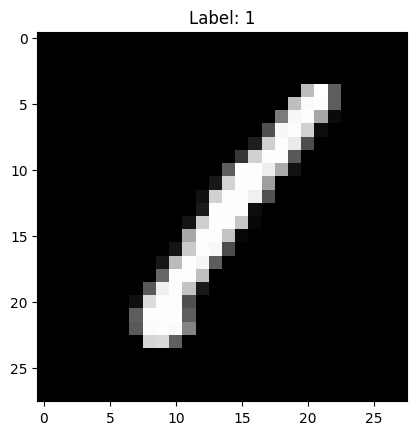

In [38]:
linha = data.iloc[0]

label = linha["label"]
pixels = linha.drop("label").values

imagem = pixels.reshape(28, 28)

plt.imshow(imagem, cmap="gray")
plt.title(f"Label: {label}")
plt.show()

# 2. Implementação para uma imagem

In [39]:
W1 = np.random.randn(8, 1, 3, 3) * np.sqrt(2 / 9)
B1 = np.zeros(8)

print(W1.shape)
print(B1.shape)

(8, 1, 3, 3)
(8,)


(8, 26, 26)


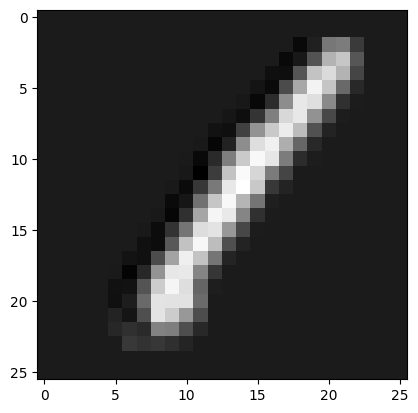

In [40]:
Z1 = np.zeros((8, 26, 26))

for k in range(8):
    kernel = W1[k, 0]
    bias = B1[k]

    for i in range(26):
        for j in range(26):
            janela = imagem[i:i+3, j:j+3]
            Z1[k, i, j] = np.sum(janela * kernel) + bias
print(Z1.shape)
plt.imshow(Z1[0], cmap="gray")

In [41]:
A1 = np.maximum(0, Z1)
A1_flat = A1.flatten()
A1_flat.shape
W2 = np.random.randn(10, 5408) * np.sqrt(2 / 5408)
B2 = np.zeros(10)
Z2 = W2 @ A1_flat + B2
exp_Z2 = np.exp(Z2 - np.max(Z2))
probs = exp_Z2 / np.sum(exp_Z2)
print(probs)
predicao = np.argmax(probs)
print("pred:",predicao)
print("real:",label)
loss = -np.log(probs[int(label)])
print("loss:",loss)

[7.00372311e-068 8.25756303e-162 1.82286384e-042 1.00000000e+000
 2.27434436e-160 3.89459089e-104 3.59573067e-045 7.79834295e-093
 6.81277776e-191 8.36617038e-055]
pred: 3
real: 1
loss: 370.90765555359445


In [42]:
y = np.zeros(10)
y[int(label)] = 1
dZ2 = probs - y
dW2 = np.outer(dZ2, A1_flat)
dB2 = dZ2
dA1_flat = W2.T @ dZ2
dA1 = dA1_flat.reshape(A1.shape)
dZ1 = dA1 * (Z1 > 0)
dB1 = np.zeros(8)

for k in range(8):
    dB1[k] = np.sum(dZ1[k])
dW1 = np.zeros_like(W1)

for k in range(8):
    for i in range(26):
        for j in range(26):
            janela = imagem[i:i+3, j:j+3]
            dW1[k, 0] += dZ1[k, i, j] * janela


In [43]:
lr = 0.00001

W2 = W2 - lr * dW2
B2 = B2 - lr * dB2

W1 = W1 - lr * dW1
B1 = B1 - lr * dB1

In [44]:
Z1 = np.zeros((8, 26, 26))

for k in range(8):
    kernel = W1[k, 0]
    bias = B1[k]

    for i in range(26):
        for j in range(26):
            janela = imagem[i:i+3, j:j+3]
            Z1[k, i, j] = np.sum(janela * kernel) + bias
A1 = np.maximum(0, Z1)
A1_flat = A1.flatten()
Z2 = W2 @ A1_flat + B2
exp_Z2 = np.exp(Z2 - np.max(Z2))
probs = exp_Z2 / np.sum(exp_Z2)
loss = -np.log(probs[int(label)])
print("loss:",loss)
print("pred:",np.argmax(probs))
print("real",label)

loss: 27.862172624731784
pred: 2
real 1


# 4. Funções para rede neural


In [45]:
def init_params():
    W1 = np.random.randn(8, 1, 3, 3) * np.sqrt(2 / 9)
    B1 = np.zeros(8)

    W2 = np.random.randn(10, 5408) * np.sqrt(2 / 5408)
    B2 = np.zeros(10)

    return W1, B1, W2, B2

def relu(Z1):
    return np.maximum(0, Z1)


def flatten(A1):
    return A1.flatten()


def dense(A1_flat, W2, B2):
    Z2 = W2 @ A1_flat + B2
    return Z2


def softmax(Z2):
    exp_Z2 = np.exp(Z2 - np.max(Z2))
    probs = exp_Z2 / np.sum(exp_Z2)

    return probs

def forward(imagem, W1, B1, W2, B2):
    Z1 = conv_vectorized(imagem, W1, B1)

    A1 = relu(Z1)

    A1_flat = flatten(A1)

    Z2 = dense(A1_flat, W2, B2)

    probs = softmax(Z2)

    return Z1, A1, A1_flat, Z2, probs


def backward_vectorized(
    imagem,
    label,
    probs,
    Z1,
    A1,
    A1_flat,
    W1,
    W2
):
    y = np.zeros(10)
    y[int(label)] = 1

    dZ2 = probs - y
    dW2 = np.outer(dZ2, A1_flat)
    dB2 = dZ2

    dA1_flat = W2.T @ dZ2


    dA1 = dA1_flat.reshape(A1.shape)



    dZ1 = dA1 * (Z1 > 0)

    janelas = sliding_window_view(imagem, (3, 3))

    janelas_flat = janelas.reshape(676, 9)

    dZ1_flat = dZ1.reshape(8, 676)

    dW1_flat = dZ1_flat @ janelas_flat

    dW1 = dW1_flat.reshape(8, 1, 3, 3)
    dB1 = np.sum(dZ1, axis=(1, 2))
    return dW1, dB1, dW2, dB2

def gradient_descent(W,DW,L):
    Wn = W - L*DW
    return Wn


def conv_vectorized(imagem, W1, B1):
    janelas = sliding_window_view(imagem, (3, 3))

    janelas_flat = janelas.reshape(676, 9)

    kernels = W1.reshape(8, 9)

    Z1 = kernels @ janelas_flat.T
    Z1 = Z1 + B1[:, None]

    Z1 = Z1.reshape(8, 26, 26)

    return Z1

def evaluate(X_set, y_set, W1, B1, W2, B2):
    loss_total, acertos = 0.0, 0
    for i in range(len(X_set)):
        imagem = X_set[i].reshape(28, 28)
        label = int(y_set[i])
        _, _, _, _, probs = forward(imagem, W1, B1, W2, B2)
        loss_total += -np.log(probs[label] + 1e-12)
        acertos += (np.argmax(probs) == label)
    return loss_total / len(X_set), acertos / len(X_set)

In [46]:
from sklearn.model_selection import train_test_split

X = data.drop(columns="label").values / 255.0
y = data["label"].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)  # 0.1765 * 0.85 ≈ 0.15 do total

print(X_train.shape, X_val.shape, X_test.shape)

(29398, 784) (6302, 784) (6300, 784)


In [47]:
W1, B1, W2, B2 = init_params()

In [48]:
lr = 0.0001
n_train = 5000
n_val = 2000
epochs = 10

hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):

    loss_total = 0
    acertos = 0

    indices = np.random.permutation(n_train)

    for i in indices:

        imagem = X_train[i].reshape(28, 28)
        label = int(y_train[i])

        # Forward
        Z1, A1, A1_flat, Z2, probs = forward(
            imagem, W1, B1, W2, B2
        )

        # Loss
        loss = -np.log(probs[label] + 1e-12)
        loss_total += loss

        # Accuracy
        if np.argmax(probs) == label:
            acertos += 1

        dW1, dB1, dW2, dB2 = backward_vectorized(
            imagem,
            label,
            probs,
            Z1,
            A1,
            A1_flat,
            W1,
            W2
        )

        W1 = gradient_descent(W1, dW1, lr)
        B1 = gradient_descent(B1, dB1, lr)

        W2 = gradient_descent(W2, dW2, lr)
        B2 = gradient_descent(B2, dB2, lr)


    train_loss = loss_total / n_train
    train_acc = acertos / n_train

    val_loss, val_acc = evaluate(
        X_val[:n_val], y_val[:n_val], W1, B1, W2, B2
    )

    hist["train_loss"].append(train_loss)
    hist["train_acc"].append(train_acc)
    hist["val_loss"].append(val_loss)
    hist["val_acc"].append(val_acc)

    print(
        f"epoch={epoch} | "
        f"train_loss={train_loss:.4f} acc={train_acc:.2%} | "
        f"val_loss={val_loss:.4f} acc={val_acc:.2%}"
    )

epoch=0 | train_loss=1.3627 acc=66.06% | val_loss=0.8226 acc=82.15%
epoch=1 | train_loss=0.6595 acc=84.66% | val_loss=0.5617 acc=85.70%
epoch=2 | train_loss=0.5001 acc=87.14% | val_loss=0.4737 acc=86.85%
epoch=3 | train_loss=0.4328 acc=88.22% | val_loss=0.4326 acc=87.30%
epoch=4 | train_loss=0.3951 acc=88.80% | val_loss=0.4070 acc=87.90%
epoch=5 | train_loss=0.3700 acc=89.46% | val_loss=0.3935 acc=87.90%
epoch=6 | train_loss=0.3512 acc=89.86% | val_loss=0.3807 acc=87.85%
epoch=7 | train_loss=0.3383 acc=90.28% | val_loss=0.3654 acc=89.20%
epoch=8 | train_loss=0.3257 acc=90.40% | val_loss=0.3593 acc=89.15%
epoch=9 | train_loss=0.3156 acc=90.88% | val_loss=0.3568 acc=89.15%


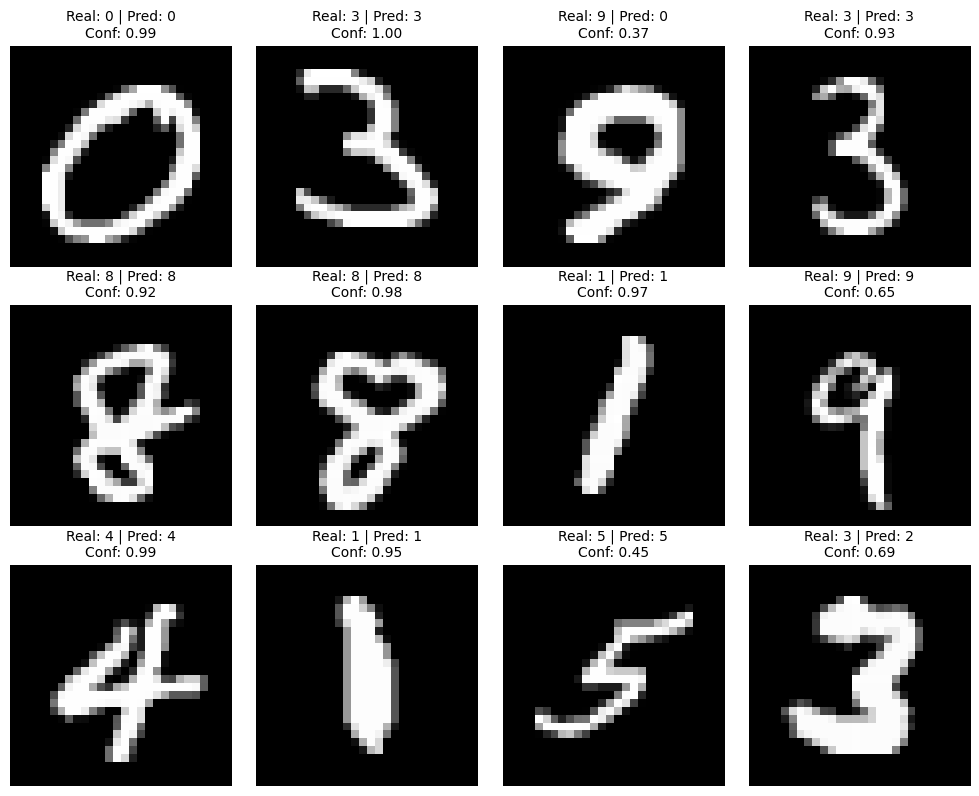

In [49]:

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

for i_ax in range(12):
  i = np.random.randint(len(X_val))
  imagem = X_val[i].reshape(28, 28)
  label_real = int(y_val[i])

  Z1, A1, A1_flat, Z2, probs = forward(imagem, W1, B1, W2, B2)
  predicao = np.argmax(probs)
  confianca = probs[predicao]

  axes[i_ax].imshow(imagem, cmap="gray")
  axes[i_ax].axis("off")

  axes[i_ax].set_title(
      f"Real: {label_real} | Pred: {predicao}\nConf: {confianca:.2f}",
      fontsize=10
  )

plt.tight_layout()
plt.show()

# 6. PyTorch CNN

In [50]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3
        )

        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3
        )

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()

        self.dense = nn.Linear(
            16 * 24 * 24,
            10
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.dense(x)

        return x

In [51]:
X_train_t = torch.tensor(
    X_train,
    dtype=torch.float32
).reshape(-1, 1, 28, 28)

y_train_t = torch.tensor(
    y_train,
    dtype=torch.long
)

X_val_t = torch.tensor(
    X_val,
    dtype=torch.float32
).reshape(-1, 1, 28, 28)

y_val_t = torch.tensor(
    y_val,
    dtype=torch.long
)

print(X_train_t.shape, X_val_t.shape)

torch.Size([29398, 1, 28, 28]) torch.Size([6302, 1, 28, 28])


In [52]:
dataset = TensorDataset(X_train_t, y_train_t)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

val_dataset = TensorDataset(X_val_t, y_val_t)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

In [53]:
torch.manual_seed(42)
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)


def evaluate_torch(model, data_loader, criterion, device):
    """Avalia sem atualizar pesos. Retorna (loss média, acurácia).

    Sempre devolve o modelo para modo train() no fim, para não deixar
    o estado eval() vazando para o próximo loop de treino.
    """
    model.eval()

    loss_total, acertos, total = 0.0, 0, 0

    with torch.no_grad():
        for imagens, labels in data_loader:
            imagens = imagens.to(device)
            labels = labels.to(device)

            logits = model(imagens)

            loss_total += criterion(logits, labels).item() * len(labels)
            acertos += (torch.argmax(logits, dim=1) == labels).sum().item()
            total += len(labels)

    model.train()

    return loss_total / total, acertos / total

In [54]:
epochs = 10

hist_torch = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

model.train()

for epoch in range(epochs):

    loss_total = 0
    acertos = 0
    total = 0

    for imagens, labels in loader:

        imagens = imagens.to(device)
        labels = labels.to(device)

        # zera gradientes anteriores
        optimizer.zero_grad()

        # forward
        logits = model(imagens)

        # loss
        loss = criterion(logits, labels)

        # backward
        loss.backward()

        # gradient descent
        optimizer.step()

        loss_total += loss.item() * len(labels)

        predicoes = torch.argmax(logits, dim=1)

        acertos += (predicoes == labels).sum().item()
        total += len(labels)

    train_loss = loss_total / total
    train_acc = acertos / total

    val_loss, val_acc = evaluate_torch(model, val_loader, criterion, device)

    hist_torch["train_loss"].append(train_loss)
    hist_torch["train_acc"].append(train_acc)
    hist_torch["val_loss"].append(val_loss)
    hist_torch["val_acc"].append(val_acc)

    print(
        f"epoch={epoch} | "
        f"train_loss={train_loss:.4f} acc={train_acc:.2%} | "
        f"val_loss={val_loss:.4f} acc={val_acc:.2%}"
    )

melhor_epoca = int(np.argmin(hist_torch["val_loss"]))


epoch=0 | train_loss=0.9854 acc=74.33% | val_loss=0.3909 acc=88.62%
epoch=1 | train_loss=0.3682 acc=89.02% | val_loss=0.3605 acc=89.65%
epoch=2 | train_loss=0.3365 acc=90.01% | val_loss=0.3544 acc=89.69%
epoch=3 | train_loss=0.3185 acc=90.71% | val_loss=0.3266 acc=90.50%
epoch=4 | train_loss=0.3086 acc=90.99% | val_loss=0.3334 acc=90.69%
epoch=5 | train_loss=0.2984 acc=91.24% | val_loss=0.3174 acc=91.24%
epoch=6 | train_loss=0.2924 acc=91.52% | val_loss=0.3302 acc=90.86%
epoch=7 | train_loss=0.2864 acc=91.64% | val_loss=0.3144 acc=90.92%
epoch=8 | train_loss=0.2782 acc=91.97% | val_loss=0.3318 acc=90.75%
epoch=9 | train_loss=0.2724 acc=92.13% | val_loss=0.3123 acc=91.13%

Menor val_loss na época 9 (0.3123) — se val_loss voltar a subir depois dela, é overfitting.


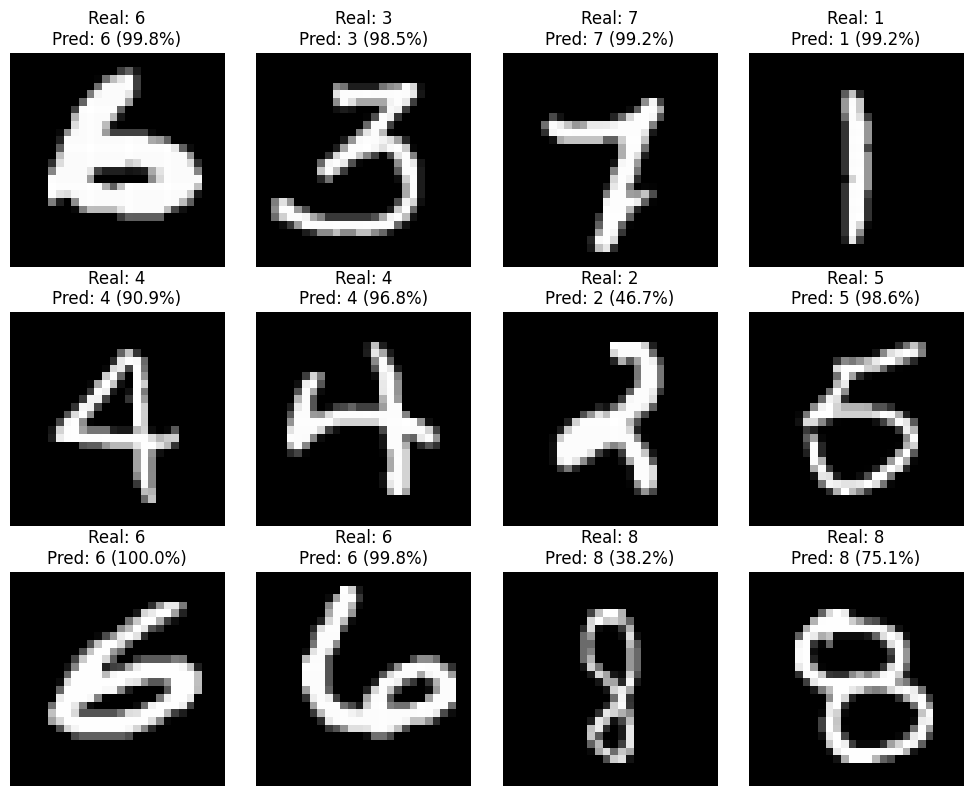

CNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense): Linear(in_features=9216, out_features=10, bias=True)
)

In [55]:

model.eval()

n_imagens = 12

indices = np.random.choice(
    len(X_val),
    size=n_imagens,
    replace=False
)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, i in zip(axes.flatten(), indices):

    imagem = torch.tensor(
        X_val[i],
        dtype=torch.float32
    ).reshape(1, 1, 28, 28).to(device)

    label_real = int(y_val[i])

    with torch.no_grad():
        logits = model(imagem)
        probs = torch.softmax(logits, dim=1)

        predicao = torch.argmax(probs, dim=1).item()
        confianca = probs[0, predicao].item()

    ax.imshow(
        X_val[i].reshape(28, 28),
        cmap="gray"
    )

    ax.set_title(
        f"Real: {label_real}\n"
        f"Pred: {predicao} ({confianca:.1%})"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

model.train()

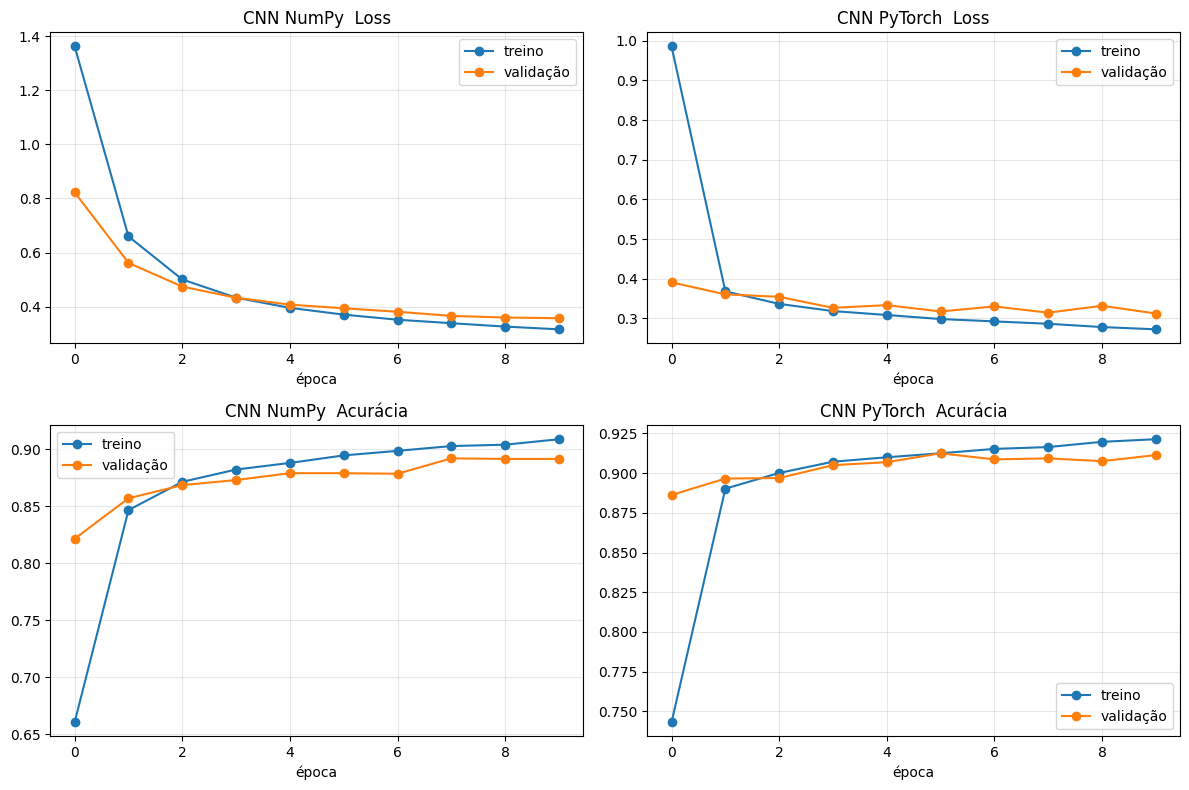

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (h, nome) in enumerate([(hist, "CNN NumPy"), (hist_torch, "CNN PyTorch")]):
    eps = range(len(h["train_loss"]))

    axes[0, col].plot(eps, h["train_loss"], marker="o", label="treino")
    axes[0, col].plot(eps, h["val_loss"], marker="o", label="validação")
    axes[0, col].set_title(f"{nome}  Loss")
    axes[0, col].set_xlabel("época")
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(eps, h["train_acc"], marker="o", label="treino")
    axes[1, col].plot(eps, h["val_acc"], marker="o", label="validação")
    axes[1, col].set_title(f"{nome}  Acurácia")
    axes[1, col].set_xlabel("época")
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 7. Avaliação final

Split: **70% treino / 15% validação / 15% teste**, estratificado por label.

- **Treino**  ajusta os pesos.
- **Validação**  mede a cada época, escolhe hiperparâmetros e detecta overfitting.
- **Teste**  tocado **uma única vez**, abaixo. Não volte a ajustar o modelo depois de ver este número.

In [57]:
# =====================================================================
# AVALIAÇÃO FINAL NO TESTE
# Rode esta célula UMA VEZ, no fim. Se depois dela você mexer em lr,
# épocas ou arquitetura, o número deixa de ser uma estimativa honesta.
# =====================================================================

n_test_numpy = 2000   # subconjunto: a rede NumPy é lenta em Python puro

# --- CNN NumPy ---
test_loss_np, test_acc_np = evaluate(
    X_test[:n_test_numpy], y_test[:n_test_numpy], W1, B1, W2, B2
)

# --- CNN PyTorch ---
X_test_t = torch.tensor(X_test, dtype=torch.float32).reshape(-1, 1, 28, 28)
y_test_t = torch.tensor(y_test, dtype=torch.long)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=256,
    shuffle=False
)

test_loss_pt, test_acc_pt = evaluate_torch(
    model, test_loader, criterion, device
)

print("=" * 62)
print(f"{'Modelo':<16}{'Val loss':>11}{'Val acc':>10}{'Test loss':>12}{'Test acc':>11}")
print("-" * 62)
print(
    f"{'CNN NumPy':<16}{hist['val_loss'][-1]:>11.4f}{hist['val_acc'][-1]:>10.2%}"
    f"{test_loss_np:>12.4f}{test_acc_np:>11.2%}"
)
print(
    f"{'CNN PyTorch':<16}{hist_torch['val_loss'][-1]:>11.4f}{hist_torch['val_acc'][-1]:>10.2%}"
    f"{test_loss_pt:>12.4f}{test_acc_pt:>11.2%}"
)
print("=" * 62)
print(
    f"\nAVISO: a comparação não é pareada — NumPy treinou em {n_train} amostras "
    f"com 1 camada conv;\nPyTorch treinou em {len(X_train)} com 2 convs. "
    "Mesma tarefa, condições diferentes."
)

Modelo             Val loss   Val acc   Test loss   Test acc
--------------------------------------------------------------
CNN NumPy            0.3568    89.15%      0.3326     90.05%
CNN PyTorch          0.3123    91.13%      0.2949     91.25%

AVISO: a comparação não é pareada — NumPy treinou em 5000 amostras com 1 camada conv;
PyTorch treinou em 29398 com 2 convs. Mesma tarefa, condições diferentes.


### 8. Geração de Submissão para o Kaggle
Este bloco carrega os dados de teste, aplica o modelo PyTorch e gera o arquivo CSV final.

In [59]:
import pandas as pd
import torch

# 1. Carregar o arquivo de teste oficial do Kaggle
test_df = pd.read_csv('test.csv')

# 2. Preparar os dados (Normalização e Reshape para 28x28)
X_kaggle = test_df.values / 255.0
X_kaggle_tensor = torch.tensor(X_kaggle, dtype=torch.float32).reshape(-1, 1, 28, 28).to(device)

# 3. Usar o modelo treinado nas células anteriores
model.eval()
all_preds = []

with torch.no_grad():
    # Processar em batches para ser eficiente
    for i in range(0, len(X_kaggle_tensor), 512):
        batch = X_kaggle_tensor[i:i+512]
        logits = model(batch)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

# 4. Criar o arquivo de submissão no formato Kaggle (ImageId, Label)
submission = pd.DataFrame({
    "ImageId": range(1, len(all_preds) + 1),
    "Label": all_preds
})

# 5. Salvar e exibir
submission.to_csv('submission.csv', index=False)
print("Submissão gerada com sucesso utilizando o modelo treinado!")
display(submission.head())

Submissão gerada com sucesso utilizando o modelo treinado!


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,7
4,5,3
